## Dataset Loading

The dataset was downloaded from Kaggle using the `opendatasets` package and loaded into a pandas DataFrame.

In [1]:
pip install opendatasets

## import libraries

In [2]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import GridSearchCV
import joblib
import os


In [3]:
od.download("https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: farhamohamed223
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction


100%|██████████| 4.16M/4.16M [00:00<00:00, 101MB/s]

In [4]:
df = pd.read_csv("/content/flight-price-prediction/Clean_Dataset.csv")

## Initial Data Exploration

The first step was to inspect the dataset structure, data types, missing values, duplicate records, and summary statistics.

In [ ]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
df.columns

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

In [5]:
df.drop(columns='Unnamed: 0', inplace= True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [ ]:
df.describe(include='object')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


### Insights

- No missing values were found.
- The dataset contains both numerical and categorical features.
- The column `Unnamed: 0` is only an index column and provides no useful information.

In [6]:
df.drop(columns='flight', inplace=True)
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Why was `flight` removed?

the feature has extremely high cardinality and behaves more like an identifier than a meaningful predictor. Keeping it would unnecessarily increase the feature space after encoding.

## Outlier Detection

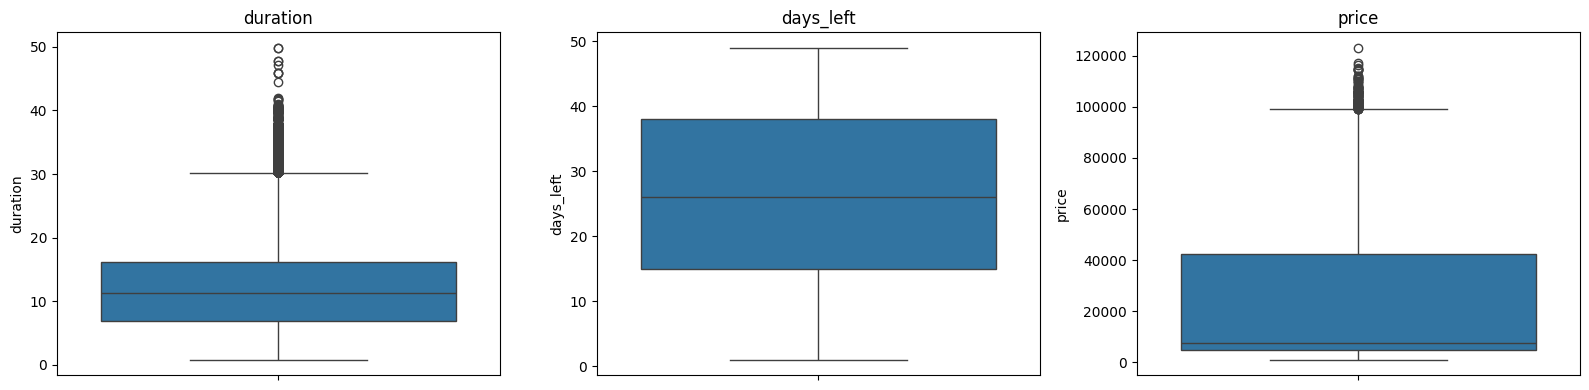

In [ ]:
numerical_coloumns = ['duration', 'days_left', 'price']

plt.figure(figsize=(16,4))
for i, col in enumerate(numerical_coloumns):
  plt.subplot(1,3,i+1)
  sns.boxplot(y = df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
for col in numerical_coloumns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")


duration: 2110 outliers
days_left: 0 outliers
price: 123 outliers


In [ ]:
df.sort_values('duration', ascending=False).head(10)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
194359,Air_India,Chennai,Evening,one,Evening,Bangalore,Economy,49.83,9,17538
193889,Air_India,Chennai,Evening,two_or_more,Evening,Bangalore,Economy,49.83,2,23891
119508,Air_India,Bangalore,Evening,one,Evening,Chennai,Economy,47.75,47,7461
261152,Air_India,Bangalore,Evening,one,Evening,Chennai,Business,47.75,47,55122
193926,Vistara,Chennai,Morning,one,Morning,Bangalore,Economy,47.08,3,17223
194650,Air_India,Chennai,Afternoon,two_or_more,Morning,Bangalore,Economy,45.83,13,12813
194141,Air_India,Chennai,Afternoon,two_or_more,Morning,Bangalore,Economy,45.83,6,12813
293606,Air_India,Chennai,Afternoon,two_or_more,Morning,Bangalore,Business,45.83,6,51928
197808,Air_India,Chennai,Evening,one,Afternoon,Kolkata,Economy,44.50,1,32439
170753,Air_India,Hyderabad,Night,one,Afternoon,Kolkata,Economy,42.00,1,33853


In [ ]:
df.groupby('stops')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
stops,,,,,,,,
one,250863.0,13.496514,6.510456,2.92,8.25,12.25,17.00,49.83
two_or_more,13286.0,15.317141,7.392067,3.92,10.00,12.67,19.08,49.83
zero,36004.0,2.191324,0.500995,0.83,1.92,2.25,2.58,3.58


In [ ]:
df.sort_values('price', ascending=False).head(10)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
261377,Vistara,Kolkata,Morning,one,Night,Delhi,Business,13.50,3,123071
216096,Vistara,Delhi,Early_Morning,two_or_more,Evening,Kolkata,Business,10.92,5,117307
215859,Vistara,Delhi,Evening,two_or_more,Evening,Kolkata,Business,21.08,1,116562
277345,Vistara,Hyderabad,Night,one,Afternoon,Mumbai,Business,16.42,3,115211
270999,Vistara,Kolkata,Morning,one,Evening,Hyderabad,Business,9.50,17,114705
290568,Vistara,Chennai,Early_Morning,one,Night,Mumbai,Business,15.08,5,114704
230092,Vistara,Mumbai,Evening,one,Evening,Bangalore,Business,22.50,2,114523
219183,Vistara,Delhi,Evening,two_or_more,Night,Hyderabad,Business,27.42,2,114507
215858,Vistara,Delhi,Evening,two_or_more,Evening,Kolkata,Business,21.08,1,114434
241548,Vistara,Mumbai,Evening,one,Evening,Chennai,Business,21.83,2,111964


In [ ]:
df.groupby('class')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Business,93487.0,52540.081124,12969.314606,12000.0,45185.0,53164.0,60396.0,123071.0
Economy,206666.0,6572.342383,3743.519517,1105.0,4173.0,5772.0,7746.0,42349.0


### Insights

- Outliers exist in `duration` and `price`.
- The outliers appear to represent legitimate long flights and expensive business-class tickets rather than data entry errors.
- Therefore, no outliers were removed.

## Exploratory Data Analysis (EDA)

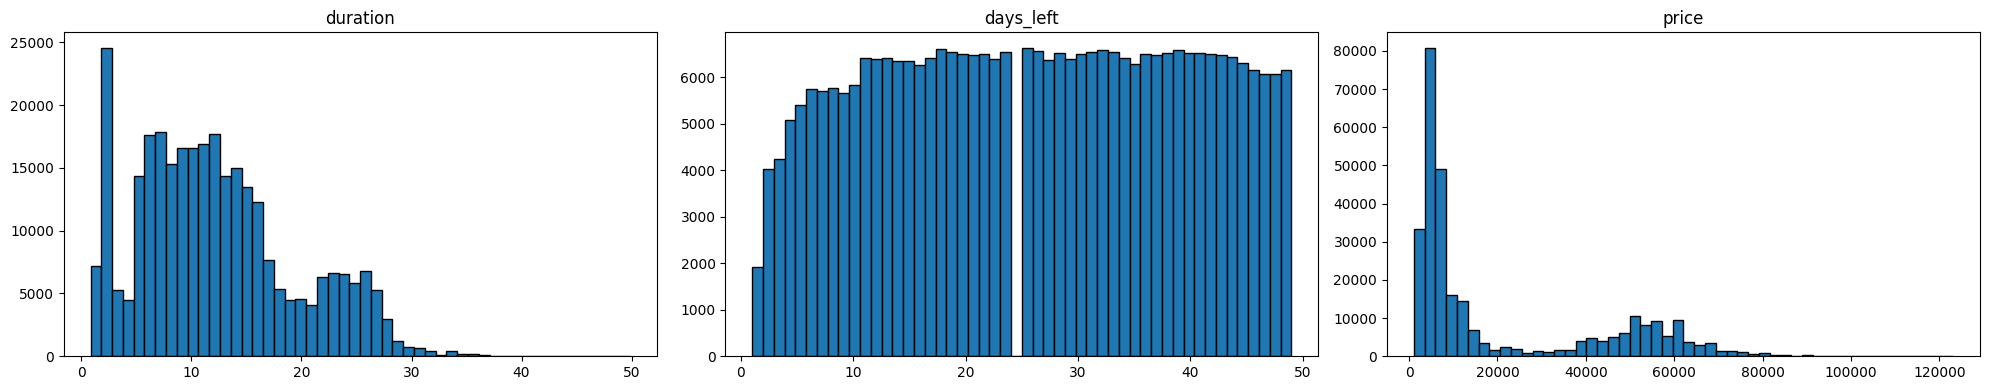

In [ ]:
plt.figure(figsize=(20,4))
for i, col in enumerate(numerical_coloumns):
  plt.subplot(1,3,i+1)
  plt.hist(df[col], bins=50, edgecolor = 'black')
  plt.title(col)

plt.tight_layout()
plt.show()

### Insights

- `duration` and `price` show right-skewed distributions.
- `days_left` has a relatively balanced distribution.

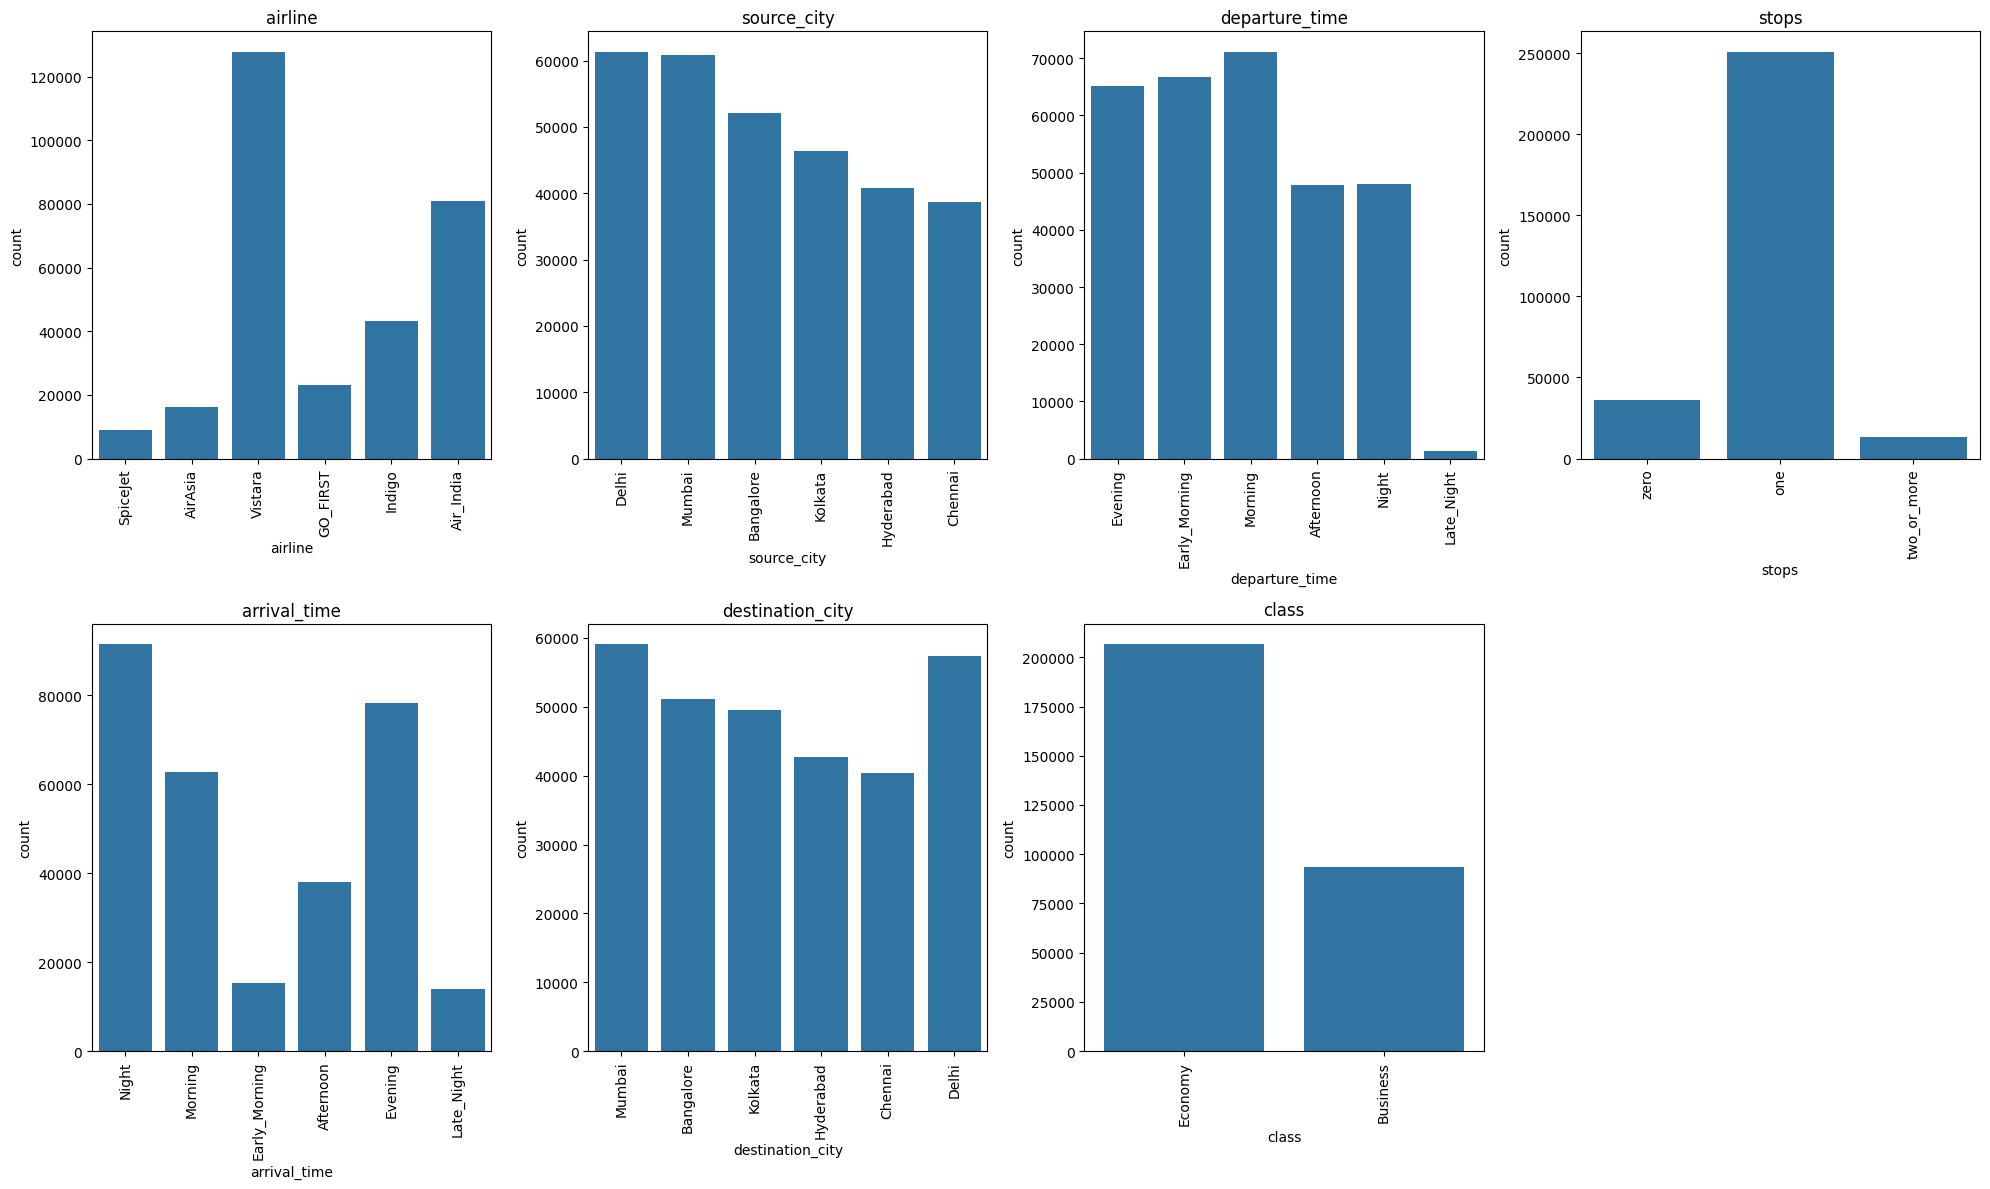

In [ ]:
Categorical_coloumns = ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

plt.figure(figsize=(20,12))
for i, col in enumerate(Categorical_coloumns):
  plt.subplot(2,4,i+1)
  sns.countplot(x = df[col])
  plt.xticks(rotation = 90)
  plt.title(col)

plt.tight_layout()
plt.show()

### Insights

- Economy class dominates the dataset.
- Some airlines appear much more frequently than others.

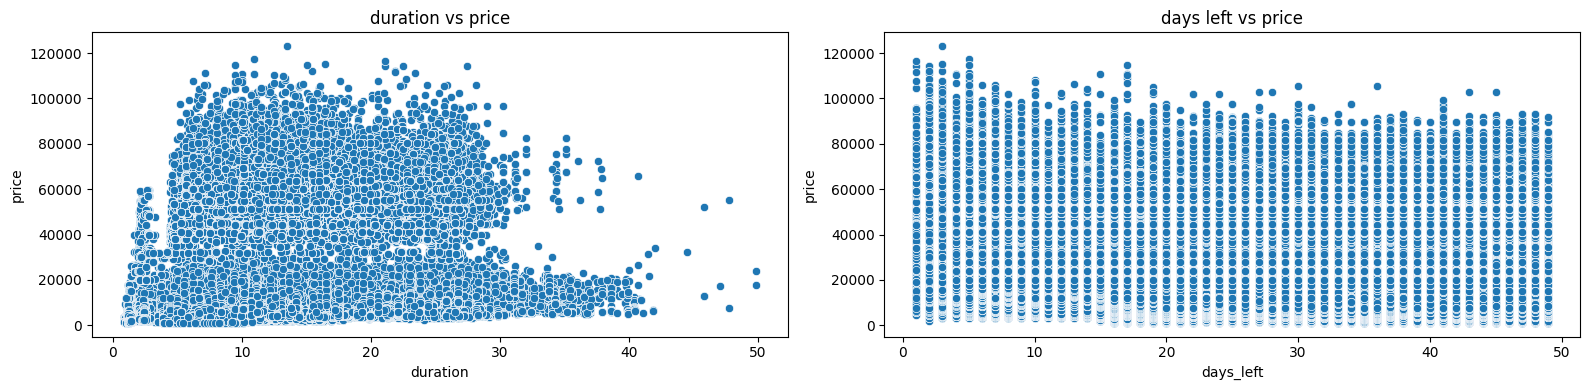

In [ ]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
sns.scatterplot(x = df['duration'], y = df['price'])
plt.title("duration vs price")

plt.subplot(1,2,2)
sns.scatterplot(x = df['days_left'], y = df['price'])
plt.title("days left vs price")

plt.tight_layout()
plt.show()

### Insights

- No strong linear relationship was observed between duration and price.
- No clear relationship was observed between days_left and price.

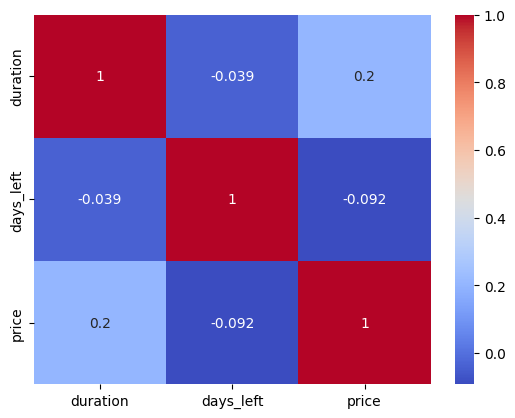

In [ ]:
sns.heatmap(df.corr(numeric_only= True), annot=True, cmap='coolwarm')
plt.show()

### Correlation Analysis

- Duration has only a weak positive correlation with price.
- Days_left has almost no linear correlation with price.

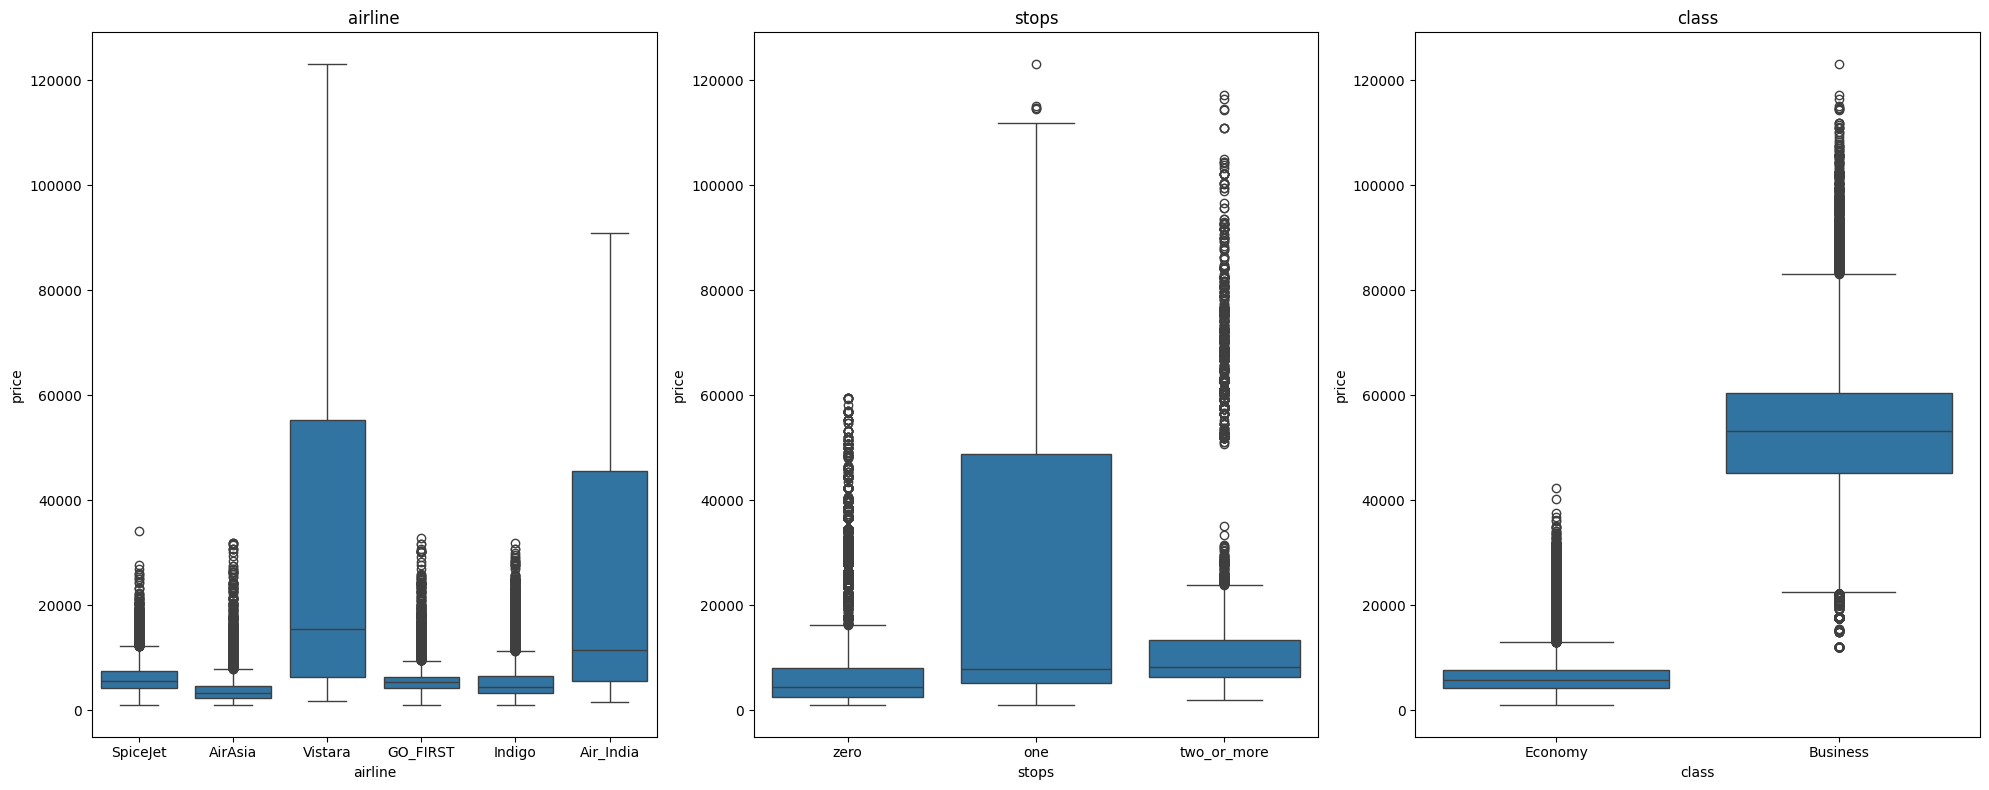

In [ ]:
columns = ['airline','stops','class']

plt.figure(figsize=(20,8))
for i, col in enumerate(columns):
  plt.subplot(1,3,i+1)
  sns.boxplot(x = df[col], y = df['price'])
  plt.title(col)

plt.tight_layout()
plt.show()


### Insights

- Business class has significantly higher ticket prices than Economy.
- Ticket prices also vary across airlines.

## Feature and Target Selection

In [7]:
x = df.drop('price', axis=1)
y = df['price']

## Data Splitting

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Feature Encoding

### Encoding Strategy

Ordinal features (`stops`, `class`, `departure_time`, `arrival_time`) were encoded using manual mappings.

Nominal features (`airline`, `source_city`, `destination_city`) were encoded using One-Hot Encoding.

In [ ]:
for col in Categorical_coloumns:
  unique_values = df[col].unique()
  print(f'unique values of {col} is: {unique_values}')

unique values of airline is: ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
unique values of source_city is: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
unique values of departure_time is: ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
unique values of stops is: ['zero' 'one' 'two_or_more']
unique values of arrival_time is: ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
unique values of destination_city is: ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
unique values of class is: ['Economy' 'Business']


In [9]:
stops_mapping = {
    'zero': 0,
    'one': 1,
    'two_or_more': 2
}

class_mapping = {
    'Economy': 0,
    'Business': 1
}

time_mapping = {
    'Early_Morning': 0,
    'Morning': 1,
    'Afternoon': 2,
    'Evening': 3,
    'Night': 4,
    'Late_Night': 5
}

In [10]:
x_train['stops'] = x_train['stops'].map(stops_mapping)
x_test['stops'] = x_test['stops'].map(stops_mapping)

x_train['class'] = x_train['class'].map(class_mapping)
x_test['class'] = x_test['class'].map(class_mapping)

x_train['departure_time'] = x_train['departure_time'].map(time_mapping)
x_test['departure_time'] = x_test['departure_time'].map(time_mapping)

x_train['arrival_time'] = x_train['arrival_time'].map(time_mapping)
x_test['arrival_time'] = x_test['arrival_time'].map(time_mapping)

In [11]:
nominal_cols = ['airline', 'source_city', 'destination_city']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = encoder.fit_transform(x_train[nominal_cols])
encoded_test = encoder.transform(x_test[nominal_cols])

encoded_train = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=x_train.index
)

encoded_test = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=x_test.index
)

x_train = x_train.drop(columns=nominal_cols)
x_test = x_test.drop(columns=nominal_cols)

x_train = pd.concat([x_train, encoded_train], axis=1)
x_test = pd.concat([x_test, encoded_test], axis=1)

## Log Transformation

In [12]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

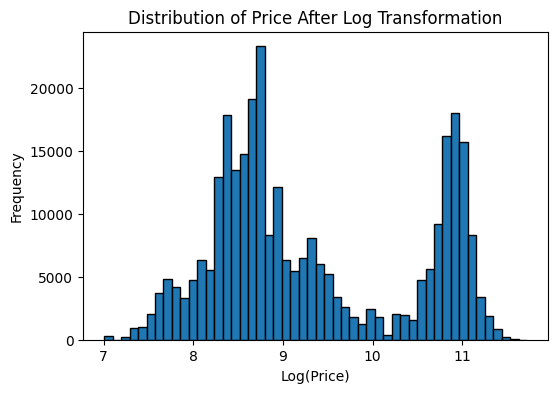

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(np.log1p(df['price']), bins=50, edgecolor='black')
plt.title('Distribution of Price After Log Transformation')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.show()

### Insights

Log Transformation reduced the right skewness of `price`.

## Feature Scaling

Standardization was applied only to models that are sensitive to feature scales such as Linear Regression and KNN.

In [ ]:
scaler = StandardScaler()

x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns=x_train.columns,
    index=x_train.index
)

x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns=x_test.columns,
    index=x_test.index
)

## Model Training

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42)
}

In [ ]:
results = []

for name, model in models.items():

    if name in ['Linear Regression', 'KNN Regressor']:
        model.fit(x_train_scaled, y_train_log)
        y_pred_log = model.predict(x_test_scaled)

    else:
        model.fit(x_train, y_train_log)
        y_pred_log = model.predict(x_test)

    y_pred = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

### Model Evaluation

Random Forest achieved the best overall performance, followed by Extra Trees.

Linear Regression produced the lowest performance among the evaluated models.

In [ ]:
results = pd.DataFrame(results)

results.sort_values(by='R2 Score', ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
3,Random Forest,1053.324090,7.644556e+06,2764.879088,0.985170
6,Extra Trees,1105.360373,8.564417e+06,2926.502500,0.983386
2,Decision Tree,1170.560737,1.267357e+07,3559.996248,0.975414
1,KNN Regressor,1758.958816,1.380876e+07,3716.013964,0.973212
4,Gradient Boosting,2948.905269,2.643670e+07,5141.663211,0.948715
5,AdaBoost,3536.202487,3.437458e+07,5862.983497,0.933316
0,Linear Regression,4620.990352,6.266536e+07,7916.145286,0.878434


## Hyperparameter Tuning

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

In [ ]:
rf = RandomForestRegressor(random_state=42)

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(x_train, y_train_log)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 20, 30], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [ ]:
print(grid_search.best_params_)

{'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
print(grid_search.best_score_)

0.9838949404436378


In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
y_pred_log = best_rf.predict(x_test)
y_pred = np.expm1(y_pred_log)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1251.3185996381071
MSE : 7986709.384539899
RMSE: 2826.0766770453874
R2  : 0.9845063355345957


After applying GridSearchCV to optimize the Random Forest hyperparameters, the tuned model did not outperform the default Random Forest model on the test set. Therefore, the default model was initially selected as the best-performing model

In [ ]:
rf.fit(x_train, y_train_log)
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [ ]:
print(os.path.getsize("random_forest_model.pkl")/(1024*1024))

1015.3043985366821


## Model Size Analysis

To make the final model more suitable for deployment, the impact of
`max_depth` on both model performance and file size was evaluated.

This experiment helps identify a good balance between prediction accuracy
and storage requirements.

In [ ]:
depths = [10, 15, 20, 25, 30, None]

for depth in depths:

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(x_train, y_train_log)

    y_pred_log = model.predict(x_test)
    y_pred = np.expm1(y_pred_log)

    r2 = r2_score(y_test, y_pred)

    filename = f"rf_depth_{depth}.pkl"
    joblib.dump(model, filename)

    size = os.path.getsize(filename) / (1024 * 1024)

    print(f"max_depth = {depth}")
    print(f"R2        = {r2:.6f}")
    print(f"Size      = {size:.2f} MB")
    print("-" * 40)

max_depth = 10
R2        = 0.962159
Size      = 11.32 MB
----------------------------------------
max_depth = 15
R2        = 0.977069
Size      = 110.99 MB
----------------------------------------
max_depth = 20
R2        = 0.984514
Size      = 404.90 MB
----------------------------------------
max_depth = 25
R2        = 0.985402
Size      = 737.26 MB
----------------------------------------
max_depth = 30
R2        = 0.985206
Size      = 936.61 MB
----------------------------------------
max_depth = None
R2        = 0.985170
Size      = 1015.30 MB
----------------------------------------


### Insights

- Increasing `max_depth` consistently increased the model size.
- The model size grew dramatically from 11 MB at depth 10 to more than 1 GB when no depth limit was applied.
- The improvement in R² became very small after `max_depth = 20`.
- Deeper trees produced significantly larger models while providing only marginal performance gains.
- Therefore, selecting an unlimited tree depth is not efficient for deployment purposes.


## Final Model Selection

Random Forest achieved the best predictive performance among all evaluated models.

An additional experiment was conducted to analyze the effect of different `max_depth` values on both prediction accuracy and model size.

Although deeper trees (`max_depth = 25`, `30`, and `None`) achieved slightly higher R² scores, they produced substantially larger model files (up to approximately 1 GB).

`max_depth = 20` provided an excellent balance between predictive performance and storage efficiency.

Therefore, the final deployed model was trained using `max_depth = 20`.


In [2]:
final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

final_model.fit(x_train, y_train_log)

NameError: name 'RandomForestRegressor' is not defined

In [ ]:
joblib.dump(final_model, "final_model.pkl")

['final_model.pkl']

In [ ]:
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [13]:
joblib.dump(x_train.columns.tolist(), "columns.pkl")

['columns.pkl']

## Feature Importance

After selecting the final Random Forest model, feature importance was analyzed to identify which variables contribute the most to predicting flight prices.

This analysis helps improve the interpretability of the model by highlighting the relative impact of each feature on the prediction.

In [ ]:
importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": final_model.feature_importances_
})

In [ ]:
grouped_importance = importance.copy()

grouped_importance["Feature"] = grouped_importance["Feature"].replace({
    r"^airline_.*": "Airline",
    r"^source_city_.*": "Source City",
    r"^destination_city_.*": "Destination City"
}, regex=True)

grouped_importance = (
    grouped_importance
    .groupby("Feature", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

grouped_importance

,Feature,Importance
4,class,0.835489
5,days_left,0.067747
7,duration,0.045826
0,Airline,0.023572
2,Source City,0.009680
1,Destination City,0.008886
3,arrival_time,0.003074
8,stops,0.003056
6,departure_time,0.002669


### Insights

Ticket class is the most influential factor affecting flight prices.

In [ ]:
from google.colab import files

files.download("final_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
print(x_test.iloc[0])

NameError: name 'x_test' is not defined